# Customer Segmentation & Churn Prediction for a Gift Retailer

**Business question:** Which customers should the CRM team talk to, what should each group hear, and who is about to stop buying?

**Data:** UCI Online Retail dataset. It contains 541,909 order lines from a UK-based online gift retailer between December 2010 and December 2011, and most of its customers are retailers and gift shops.

**Approach**
1. Clean the transactions.
2. Score every customer on **Recency, Frequency and Spend** (RFM), then group them into 7 marketing segments.
3. Validate the segments with **K-Means clustering**.
4. Predict **churn**, meaning no purchase in the next 90 days, with an out-of-time test so the model never sees the future.
5. Turn the results into a **segment playbook** and a prioritised **win-back list**.

In [1]:
import sys, json, warnings
from pathlib import Path
sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve, precision_score, recall_score
from sklearn.inspection import permutation_importance

from data import load_clean
from segmentation import build_rfm, score_rfm, kmeans_diagnostics, fit_kmeans
from churn import build_features, build_labels, candidate_models, compare_models, lift_table, FEATURES

OUT = Path.cwd().parent / "outputs"
CHARTS = OUT / "charts"
CHARTS.mkdir(parents=True, exist_ok=True)

# Chart style: one blue for single-series charts, fixed categorical order for multi-series
BLUE, ORANGE, AQUA, GREY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 160, "savefig.bbox": "tight",
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.edgecolor": "#c9c8c3", "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e",
    "axes.grid": True, "grid.color": "#ecebe8", "axes.axisbelow": True,
    "font.size": 10, "axes.titlesize": 12, "axes.titleweight": "bold",
})
results = {}

## 1. Data cleaning

In [2]:
orders, cleaning_log = load_clean()
results["cleaning"] = cleaning_log
pd.Series(cleaning_log, name="rows").to_frame()

,rows
raw_rows,541909
after_dropping_guest_checkouts,406829
after_dropping_cancellations,397924
after_dropping_non_product_lines,396470
final_rows,391283


Guest checkouts (no customer ID) can't be targeted, so they are dropped. Cancellations, returns, postage and manual adjustments are removed because they are not purchase behaviour.

In [3]:
snapshot = orders["InvoiceDate"].max().normalize() + pd.Timedelta(days=1)
print(f"Customers: {orders.CustomerID.nunique():,} | Orders: {orders.InvoiceNo.nunique():,} | "
      f"Products: {orders.StockCode.nunique():,} | Countries: {orders.Country.nunique()}")
print("Snapshot date:", snapshot.date())

Customers: 4,334 | Orders: 18,405 | Products: 3,660 | Countries: 37
Snapshot date: 2011-12-10


## 2. RFM segmentation

In [4]:
rfm = score_rfm(build_rfm(orders, snapshot))
seg_order = ["Champions", "Loyal Customers", "New / Promising", "Needs Attention",
             "At Risk", "Can't Lose Them", "Hibernating"]
profile = (rfm.groupby("Segment")
              .agg(customers=("R", "size"), median_recency_days=("Recency", "median"),
                   median_orders=("Frequency", "median"), median_spend=("Spend", "median"),
                   spend_total=("Spend", "sum"))
              .reindex(seg_order))
profile["share_of_customers"] = profile["customers"] / profile["customers"].sum()
profile["share_of_spend"] = profile["spend_total"] / profile["spend_total"].sum()
profile = profile.drop(columns="spend_total")
profile.style.format({"median_spend": "£{:,.0f}", "share_of_customers": "{:.0%}", "share_of_spend": "{:.0%}"})

,customers,median_recency_days,median_orders,median_spend,share_of_customers,share_of_spend
Segment,,,,,,
Champions,1178,11.000000,6.000000,"£2,119",27%,70%
Loyal Customers,639,42.000000,3.000000,"£1,010",15%,12%
New / Promising,400,18.000000,1.000000,£288,9%,1%
Needs Attention,393,52.000000,1.000000,£304,9%,2%
At Risk,185,148.000000,2.000000,£664,4%,3%
Can't Lose Them,347,115.000000,4.000000,"£1,339",8%,8%
Hibernating,1192,214.000000,1.000000,£280,28%,4%


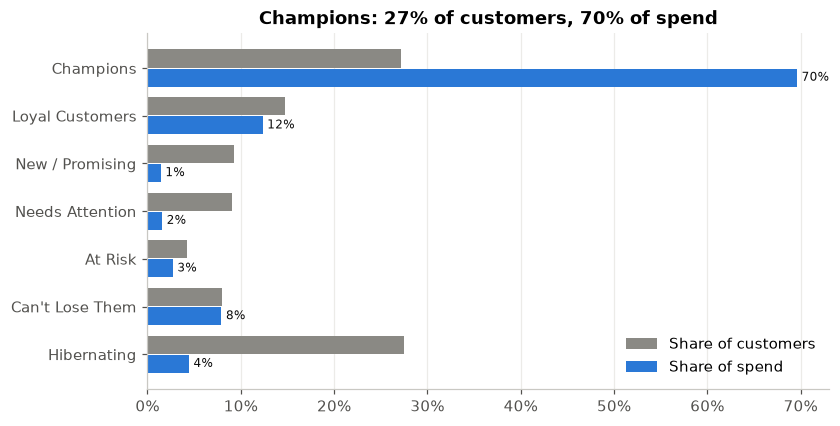

In [5]:
fig, ax = plt.subplots(figsize=(8, 4.2))
p = profile.iloc[::-1]
y = np.arange(len(p))
ax.barh(y + 0.2, p["share_of_customers"], height=0.38, color=GREY, label="Share of customers")
ax.barh(y - 0.2, p["share_of_spend"], height=0.38, color=BLUE, label="Share of spend")
ax.set_yticks(y, p.index)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
for i, (c, s) in enumerate(zip(p["share_of_customers"], p["share_of_spend"])):
    ax.text(s + 0.005, i - 0.2, f"{s:.0%}", va="center", fontsize=8, color="#0b0b0b")
ax.set_title("Champions: 27% of customers, 70% of spend")
ax.legend(frameon=False, loc="lower right")
ax.grid(axis="y", visible=False)
fig.savefig(CHARTS / "01_segment_share.png"); plt.show()

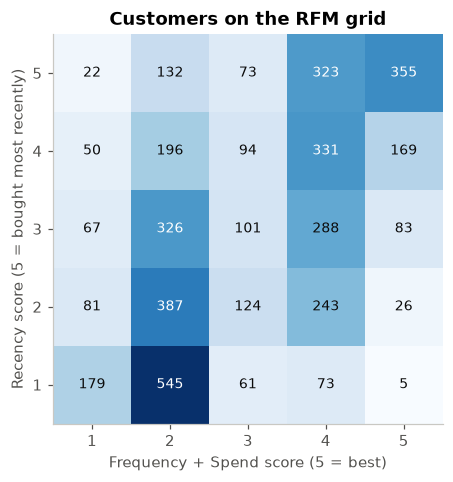

In [6]:
grid = rfm.pivot_table(index="R", columns="FM", values="Recency", aggfunc="size").sort_index(ascending=False)
fig, ax = plt.subplots(figsize=(6, 4.6))
im = ax.imshow(grid.values, cmap="Blues")
ax.set_xticks(range(grid.shape[1]), grid.columns); ax.set_yticks(range(grid.shape[0]), grid.index)
ax.set_xlabel("Frequency + Spend score (5 = best)"); ax.set_ylabel("Recency score (5 = bought most recently)")
for i in range(grid.shape[0]):
    for j in range(grid.shape[1]):
        v = grid.values[i, j]
        ax.text(j, i, f"{int(v)}", ha="center", va="center", fontsize=9,
                color="white" if v > grid.values.max() * 0.55 else "#0b0b0b")
ax.grid(False)
ax.set_title("Customers on the RFM grid")
fig.savefig(CHARTS / "02_rfm_grid.png"); plt.show()

## 3. Cross-checking the segments with K-Means

The RFM segments are rule-based, so I also let an unsupervised model find natural groups on log-scaled Recency, Frequency and Spend and checked that the two methods agree.

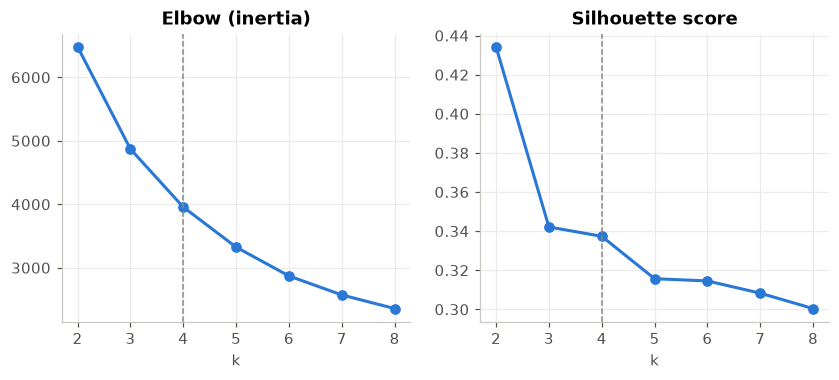

,k,inertia,silhouette
0,2,6481.795,0.434
1,3,4871.387,0.342
2,4,3956.194,0.337
3,5,3325.470,0.316
4,6,2871.007,0.315
5,7,2571.889,0.308
6,8,2357.243,0.300


In [7]:
diag = kmeans_diagnostics(rfm)
fig, (a1, a2) = plt.subplots(1, 2, figsize=(9, 3.4))
a1.plot(diag.k, diag.inertia, marker="o", color=BLUE, lw=2, ms=6); a1.set_title("Elbow (inertia)"); a1.set_xlabel("k")
a2.plot(diag.k, diag.silhouette, marker="o", color=BLUE, lw=2, ms=6); a2.set_title("Silhouette score"); a2.set_xlabel("k")
for a in (a1, a2): a.axvline(4, color=GREY, ls="--", lw=1)
fig.savefig(CHARTS / "03_kmeans_k.png"); plt.show()
diag.round(3)

k = 2 has the highest silhouette, but it only splits customers into 'active' and 'inactive', which is too coarse to act on. The elbow bends at **k = 4**, where the silhouette is still about 0.34, so I use 4 clusters.

In [8]:
K = 4
rfm["Cluster"] = fit_kmeans(rfm, K)
clusters = rfm.groupby("Cluster").agg(customers=("R", "size"), median_recency_days=("Recency", "median"),
                                      median_orders=("Frequency", "median"), median_spend=("Spend", "median"))
cluster_names = {0: "Active high-value", 1: "Recent occasional buyers", 2: "Lapsing regulars", 3: "Lost one-timers"}
clusters.index = [f"{i}: {cluster_names[i]}" for i in clusters.index]
clusters

,customers,median_recency_days,median_orders,median_spend
0: Active high-value,690,8.0,10.0,3715.435
1: Recent occasional buyers,821,16.0,2.0,470.800
2: Lapsing regulars,1179,53.0,4.0,1352.000
3: Lost one-timers,1644,173.0,1.0,295.465


In [9]:
xt = pd.crosstab(rfm["Segment"], rfm["Cluster"].map(cluster_names), normalize="index").reindex(seg_order)
xt = xt[[cluster_names[i] for i in range(K)]]
xt.style.format("{:.0%}").background_gradient(cmap="Blues", axis=None)

Cluster,Active high-value,Recent occasional buyers,Lapsing regulars,Lost one-timers
Segment,,,,
Champions,56%,15%,29%,0%
Loyal Customers,4%,29%,65%,2%
New / Promising,0%,97%,0%,3%
Needs Attention,0%,18%,5%,77%
At Risk,0%,0%,34%,66%
Can't Lose Them,1%,0%,93%,5%
Hibernating,0%,0%,1%,99%


The two methods agree closely. 99% of Hibernating customers fall in *Lost one-timers*, 97% of New / Promising in *Recent occasional buyers*, and 93% of Can't Lose Them in *Lapsing regulars*. Champions split between *Active high-value* (56%) and *Lapsing regulars* (29%), which shows that even top customers need to be watched for slowing down. So the rule-based segments match structure that is really in the data.

## 4. Churn prediction

**Definition:** a customer has *churned* if they make **no purchase in the 90 days** after a cutoff date.

**Out-of-time validation** keeps the model from seeing the future:

| | Features from orders before | Churn label from |
|---|---|---|
| Train | 12 Jun 2011 | 12 Jun to 10 Sep 2011 |
| Test | 10 Sep 2011 | 10 Sep to 9 Dec 2011 |

The model is trained on one period and tested on a later one it has never seen, which is how it would be used in a real CRM.

In [10]:
train_cut = snapshot - pd.Timedelta(days=180)
test_cut = snapshot - pd.Timedelta(days=90)

X_tr = build_features(orders, train_cut); y_tr = build_labels(orders, X_tr.index, train_cut)
X_te = build_features(orders, test_cut);  y_te = build_labels(orders, X_te.index, test_cut)
print(f"Train: {len(X_tr):,} customers, churn rate {y_tr.mean():.1%}")
print(f"Test:  {len(X_te):,} customers, churn rate {y_te.mean():.1%}")
X_te.describe().T.round(1)

Train: 2,819 customers, churn rate 52.4%
Test:  3,368 customers, churn rate 43.0%


,count,mean,std,min,25%,50%,75%,max
recency_days,3368.0,95.2,80.1,1.0,26.0,74.0,152.0,283.0
frequency,3368.0,3.5,5.7,1.0,1.0,2.0,4.0,131.0
total_spend,3368.0,1592.5,6102.2,2.9,261.2,555.0,1360.8,177729.6
tenure_days,3368.0,182.8,80.5,1.0,123.0,193.0,265.0,283.0
avg_order_value,3368.0,396.1,1430.0,2.9,167.1,279.1,409.2,77183.6
avg_items_per_order,3368.0,243.4,1312.7,1.0,83.9,149.0,258.1,74215.0
distinct_products,3368.0,49.8,67.5,1.0,14.0,29.0,63.0,1229.0
avg_days_between_orders,3368.0,93.6,76.1,0.0,35.0,67.0,142.0,283.0
orders_last_90d,3368.0,1.2,2.1,0.0,0.0,1.0,1.0,46.0
spend_trend,3368.0,0.3,0.4,0.0,0.0,0.2,0.5,1.0


In [11]:
cv = compare_models(X_tr, y_tr)
cv.round(3)

,model,cv_auc_mean,cv_auc_std
0,Logistic Regression,0.758,0.022
1,Gradient Boosting,0.738,0.024
2,Random Forest,0.737,0.024


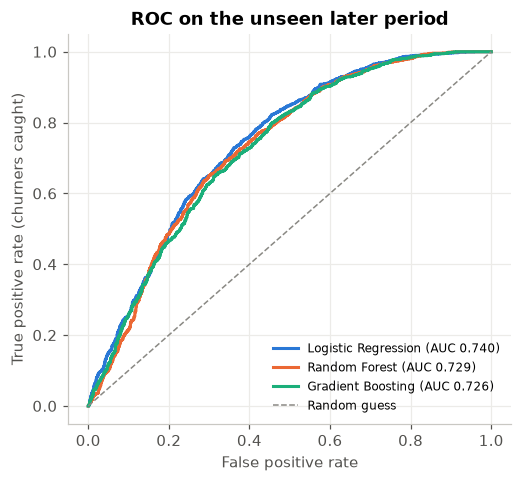

Logistic Regression    0.740
Random Forest          0.729
Gradient Boosting      0.726
Name: test_auc, dtype: float64

In [12]:
models = candidate_models()
test_auc, probas = {}, {}
for name, m in models.items():
    m.fit(X_tr, y_tr)
    probas[name] = m.predict_proba(X_te)[:, 1]
    test_auc[name] = roc_auc_score(y_te, probas[name])

fig, ax = plt.subplots(figsize=(5.2, 4.6))
for (name, p), c in zip(probas.items(), [BLUE, ORANGE, AQUA]):
    fpr, tpr, _ = roc_curve(y_te, p)
    ax.plot(fpr, tpr, lw=2, color=c, label=f"{name} (AUC {test_auc[name]:.3f})")
ax.plot([0, 1], [0, 1], color=GREY, ls="--", lw=1, label="Random guess")
ax.set_xlabel("False positive rate"); ax.set_ylabel("True positive rate (churners caught)")
ax.set_title("ROC on the unseen later period"); ax.legend(frameon=False, loc="lower right", fontsize=8)
fig.savefig(CHARTS / "04_roc.png"); plt.show()
pd.Series(test_auc, name="test_auc").round(3)

Logistic Regression does as well as the tree models or better, and it is **explainable**: a CRM manager can see why a customer is flagged. I picked it as the final model.

In [13]:
best = "Logistic Regression"
model, p_te = models[best], probas[best]
thr = 0.5
pred = (p_te >= thr).astype(int)
lift = lift_table(y_te, p_te)
top2 = lift.loc[[1, 2]]
summary = {
    "model": best,
    "test_auc": round(test_auc[best], 3),
    "cv_auc": round(float(cv.set_index("model").loc[best, "cv_auc_mean"]), 3),
    "precision": round(precision_score(y_te, pred), 3),
    "recall": round(recall_score(y_te, pred), 3),
    "base_churn_rate": round(float(y_te.mean()), 3),
    "top_decile_churn_rate": round(float(lift.loc[1, "churn_rate"]), 3),
    "top_decile_lift": round(float(lift.loc[1, "lift"]), 2),
    "top_20pct_share_of_churners": round(float(lift.loc[2, "cum_share_of_churners"]), 3),
    "top_30pct_share_of_churners": round(float(lift.loc[3, "cum_share_of_churners"]), 3),
}
results["churn_model"] = summary
summary

{'model': 'Logistic Regression',
 'test_auc': 0.74,
 'cv_auc': 0.758,
 'precision': 0.589,
 'recall': 0.763,
 'base_churn_rate': 0.43,
 'top_decile_churn_rate': 0.682,
 'top_decile_lift': 1.59,
 'top_20pct_share_of_churners': 0.308,
 'top_30pct_share_of_churners': 0.452}

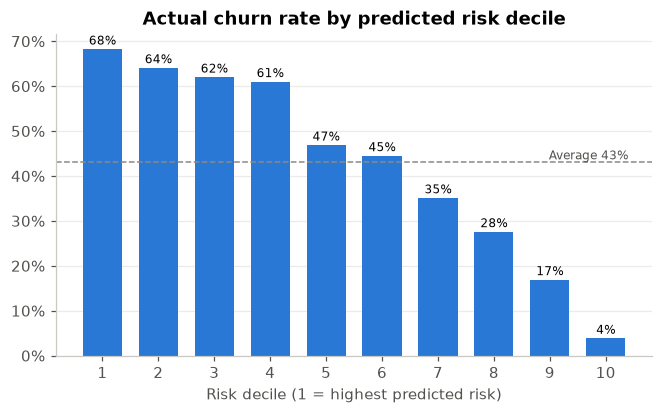

,customers,churners,churn_rate,lift,cum_share_of_churners
decile,,,,,
1,337,230,0.682,1.586,0.159
2,337,216,0.641,1.490,0.308
3,337,209,0.620,1.442,0.452
4,336,205,0.610,1.418,0.594
5,337,158,0.469,1.090,0.703
6,337,150,0.445,1.035,0.806
7,336,118,0.351,0.816,0.888
8,337,93,0.276,0.641,0.952
9,337,57,0.169,0.393,0.991


In [14]:
fig, ax = plt.subplots(figsize=(7, 3.8))
ax.bar(lift.index.astype(int), lift["churn_rate"], color=BLUE, width=0.7)
ax.axhline(y_te.mean(), color=GREY, ls="--", lw=1)
ax.text(10.4, y_te.mean(), f"Average {y_te.mean():.0%}", va="bottom", ha="right", fontsize=8, color="#52514e")
for d, r in zip(lift.index.astype(int), lift["churn_rate"]):
    ax.text(d, r + 0.01, f"{r:.0%}", ha="center", fontsize=8)
ax.set_xticks(range(1, 11)); ax.set_xlabel("Risk decile (1 = highest predicted risk)")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Actual churn rate by predicted risk decile"); ax.grid(axis="x", visible=False)
fig.savefig(CHARTS / "05_lift.png"); plt.show()
lift.round(3)

### What drives churn?

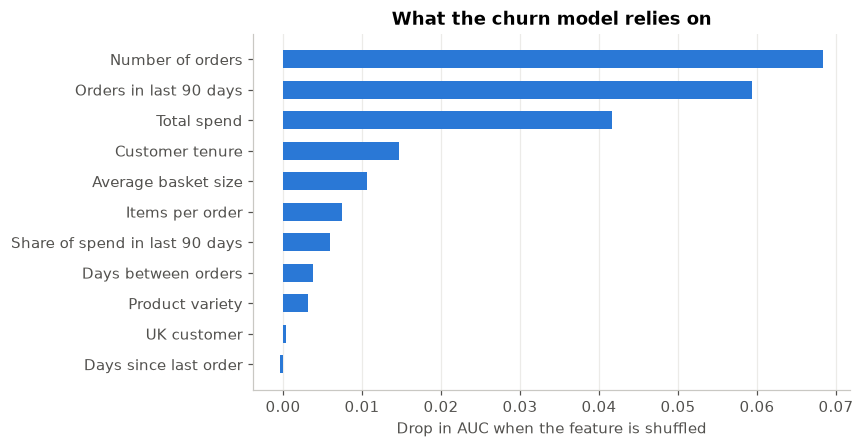

,importance,direction
frequency,0.0684,lowers churn risk
orders_last_90d,0.0594,lowers churn risk
total_spend,0.0417,lowers churn risk
tenure_days,0.0146,raises churn risk
avg_order_value,0.0107,raises churn risk
avg_items_per_order,0.0074,lowers churn risk
spend_trend,0.0059,raises churn risk
avg_days_between_orders,0.0038,lowers churn risk
distinct_products,0.0032,lowers churn risk
is_uk,0.0004,lowers churn risk


In [15]:
imp = permutation_importance(model, X_te, y_te, scoring="roc_auc", n_repeats=20, random_state=42)
imp = pd.Series(imp.importances_mean, index=FEATURES).sort_values()
coef = pd.Series(model.named_steps["clf"].coef_[0], index=FEATURES)
labels = {"recency_days": "Days since last order", "frequency": "Number of orders", "total_spend": "Total spend",
          "tenure_days": "Customer tenure", "avg_order_value": "Average basket size", "avg_items_per_order": "Items per order",
          "distinct_products": "Product variety", "avg_days_between_orders": "Days between orders",
          "orders_last_90d": "Orders in last 90 days", "spend_trend": "Share of spend in last 90 days", "is_uk": "UK customer"}
fig, ax = plt.subplots(figsize=(7, 4.2))
ax.barh([labels[f] for f in imp.index], imp.values, color=BLUE, height=0.6)
ax.set_xlabel("Drop in AUC when the feature is shuffled"); ax.set_title("What the churn model relies on")
ax.grid(axis="y", visible=False)
fig.savefig(CHARTS / "06_drivers.png"); plt.show()
pd.DataFrame({"importance": imp, "direction": np.sign(coef[imp.index]).map({1: "raises churn risk", -1: "lowers churn risk"})}).iloc[::-1].round(4)

## 5. Connecting segments and churn

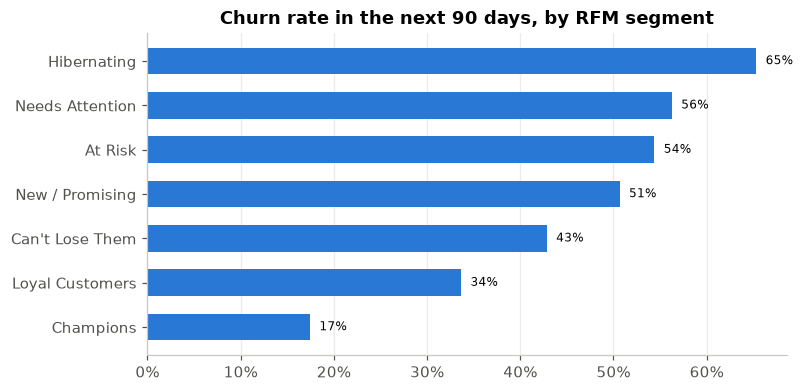

,customers,churn_rate
Segment,,
Champions,951,17%
Loyal Customers,505,34%
New / Promising,298,51%
Needs Attention,279,56%
At Risk,125,54%
Can't Lose Them,238,43%
Hibernating,972,65%


In [16]:
rfm_at_test = score_rfm(build_rfm(orders[orders.InvoiceDate < test_cut], test_cut))
seg_churn = (rfm_at_test.join(y_te).groupby("Segment")
             .agg(customers=("churned", "size"), churn_rate=("churned", "mean"))
             .reindex(seg_order))
fig, ax = plt.subplots(figsize=(7.5, 3.8))
s = seg_churn.sort_values("churn_rate")
ax.barh(s.index, s["churn_rate"], color=BLUE, height=0.6)
for i, r in enumerate(s["churn_rate"]):
    ax.text(r + 0.01, i, f"{r:.0%}", va="center", fontsize=8)
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f"{v:.0%}"))
ax.set_title("Churn rate in the next 90 days, by RFM segment"); ax.grid(axis="y", visible=False)
fig.savefig(CHARTS / "07_churn_by_segment.png"); plt.show()
results["churn_by_segment"] = seg_churn["churn_rate"].round(3).to_dict()
seg_churn.style.format({"churn_rate": "{:.0%}"})

## 6. Win-back list for the CRM team

I retrain the model on the most recent period and score every customer as of the snapshot date. The result is a ranked list of who is likely to lapse in the next 90 days, with the segment and recommended action next to each one.

In [17]:
final = candidate_models()[best].fit(X_te, y_te)
X_now = build_features(orders, snapshot)
risk = pd.Series(final.predict_proba(X_now)[:, 1], index=X_now.index, name="churn_risk")

playbook = {
    "Champions": ("Reward & advocate", "Early access to new collections, referral programme, ask for reviews", "Email + loyalty"),
    "Loyal Customers": ("Upsell & deepen", "Personalised bundles, cross-sell from purchase history, tier upgrade", "Email"),
    "New / Promising": ("Onboard", "Welcome series, second-order incentive, bestseller recommendations", "Email + retargeting"),
    "Needs Attention": ("Re-engage", "Limited-time offer on previously viewed categories", "Email + retargeting"),
    "At Risk": ("Win back", "Personal 'we miss you' message, free shipping, new-arrival preview", "Email + paid social"),
    "Can't Lose Them": ("Urgent win back", "Account-manager call, exclusive offer, feedback survey", "Phone + email"),
    "Hibernating": ("Low-cost reactivation", "Seasonal campaign only; suppress if no response to save send volume", "Email (low frequency)"),
}
winback = rfm[["Segment", "Recency", "Frequency", "Spend"]].join(risk)
winback["action"] = winback["Segment"].map(lambda s: playbook[s][0])
winback["priority"] = np.where((winback.churn_risk >= 0.5) & winback.Segment.isin(["Champions", "Loyal Customers", "Can't Lose Them", "At Risk"]),
                               "High", np.where(winback.churn_risk >= 0.5, "Medium", "Low"))
winback = winback.sort_values(["priority", "churn_risk"], key=lambda c: c.map({"High": 0, "Medium": 1, "Low": 2}) if c.name == "priority" else -c)
winback.round(3).to_csv(OUT / "winback_list.csv")
results["winback_counts"] = winback["priority"].value_counts().to_dict()
print(winback["priority"].value_counts())
winback.head(10).round(2)

priority
Low       2337
Medium    1766
High       231
Name: count, dtype: int64


,Segment,Recency,Frequency,Spend,churn_risk,action,priority
CustomerID,,,,,,,
17391,At Risk,163,2,508.80,0.85,Win back,High
15098,Can't Lose Them,182,3,39916.50,0.84,Urgent win back,High
15649,At Risk,336,2,816.00,0.82,Win back,High
16766,Can't Lose Them,273,2,1145.60,0.81,Urgent win back,High
16692,Can't Lose Them,256,2,1126.00,0.81,Urgent win back,High
18087,Can't Lose Them,290,1,3202.92,0.80,Urgent win back,High
18133,At Risk,212,1,931.50,0.80,Win back,High
16716,At Risk,266,2,901.20,0.80,Win back,High
13135,At Risk,196,1,3096.00,0.79,Win back,High


In [18]:
pb = pd.DataFrame(playbook, index=["Goal", "Campaign idea", "Channel"]).T.reindex(seg_order)
pb.insert(0, "Customers", profile["customers"])
pb.insert(1, "90-day churn rate", seg_churn["churn_rate"].map("{:.0%}".format))
pb.to_csv(OUT / "segment_playbook.csv")
rfm.to_csv(OUT / "customer_segments.csv")
(OUT / "results.json").write_text(json.dumps(results, indent=2, default=str))
pb

,Customers,90-day churn rate,Goal,Campaign idea,Channel
Champions,1178,17%,Reward & advocate,"Early access to new collections, referral prog...",Email + loyalty
Loyal Customers,639,34%,Upsell & deepen,"Personalised bundles, cross-sell from purchase...",Email
New / Promising,400,51%,Onboard,"Welcome series, second-order incentive, bestse...",Email + retargeting
Needs Attention,393,56%,Re-engage,Limited-time offer on previously viewed catego...,Email + retargeting
At Risk,185,54%,Win back,"Personal 'we miss you' message, free shipping,...",Email + paid social
Can't Lose Them,347,43%,Urgent win back,"Account-manager call, exclusive offer, feedbac...",Phone + email
Hibernating,1192,65%,Low-cost reactivation,Seasonal campaign only; suppress if no respons...,Email (low frequency)


## 7. Key takeaways

* **A small group drives the business.** Champions are 27% of customers but 70% of spend, and they have the lowest churn rate (17%). Protecting them is the top CRM priority.
* **Recent activity is the strongest churn signal.** Customers who ordered recently and often in the last 90 days rarely churn. Hibernating (65%) and Needs Attention (56%) customers churn the most.
* **The model ranks risk well on data it has never seen** (out-of-time AUC 0.74). The 40% of customers it rates riskiest churn at 63%, against a 43% average, and include 59% of all churners. The 30% it rates safest churn at only 16%, so they can be left out of win-back discounts.
* **Each segment gets a different message.** Champions get rewards, At Risk customers get personal win-back, and Hibernating customers get low-frequency seasonal sends so they are not over-messaged.

**Limitations:** this is one retailer over 12 months; most customers are wholesale buyers, so ordering is seasonal (the Q4 gift peak); and there is no web, email or demographic data.

**Next steps:** add email engagement data and A/B test the win-back offers against a hold-out group to measure the real uplift in retention.